In [1]:
!pip install --upgrade --no-cache-dir "sagemaker<3" pandas numpy matplotlib seaborn scikit-learn "torch==2.6" torchvision sagemaker boto3

INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.


In [3]:
import sagemaker

sess = sagemaker.Session()
bucket = sess.default_bucket()
prefix = "sagemaker"

import boto3
import re
from sagemaker import get_execution_role

role = get_execution_role()

In [ ]:
import struct

from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sagemaker.s3 import S3Uploader

In [10]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [11]:
class CustomDataset(Dataset):
    def __init__(self, images, labels=None, transform=None):
        self.images    = images
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = torch.FloatTensor(self.images[idx])

        if self.transform:
            img = self.transform(img)

        if self.labels is not None:
            return img, int(self.labels[idx])
        return img

In [12]:
with open('./dataset/train-images.idx3-ubyte', 'rb') as f:
    _, n, rows, cols = struct.unpack('>IIII', f.read(16))
    images = np.fromfile(f, dtype=np.uint8).reshape(n, 1, rows, cols)

with open('./dataset/train-labels.idx1-ubyte', 'rb') as f:
    struct.unpack('>II', f.read(8))
    labels = np.fromfile(f, dtype=np.uint8)

with open('./dataset/t10k-images.idx3-ubyte', 'rb') as f:
    _, n, rows, cols = struct.unpack('>IIII', f.read(16))
    test_images = np.fromfile(f, dtype=np.uint8).reshape(n, 1, rows, cols)

with open('./dataset/t10k-labels.idx1-ubyte', 'rb') as f:
    struct.unpack('>II', f.read(8))
    test_labels = np.fromfile(f, dtype=np.uint8)

images      = images.astype(np.float32) / 255.0
test_images = test_images.astype(np.float32) / 255.0

train_dataset = CustomDataset(images, labels)
test_dataset  = CustomDataset(test_images, test_labels)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64)

In [5]:
%%bash

curl -L -o ./mnist.zip https://www.kaggle.com/api/v1/datasets/download/hojjatk/mnist-dataset

mkdir mnist
unzip -q mnist.zip -d ./mnist

mkdir dataset
mv mnist/* dataset/

rm mnist.zip
zip -rq mnist.zip dataset/

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0   0     0   0     0     0     0  --:--:-- --:--:-- --:--:--     0
100 22570k 100 22570k   0     0 51011k     0  --:--:-- --:--:-- --:--:-- 51011k


In [6]:
inputs = S3Uploader.upload("mnist.zip", "s3://{}/{}".format(bucket, prefix))

In [46]:
from sagemaker.tensorflow import TensorFlow

estimator = TensorFlow(
    entry_point="train.py",
    framework_version="2.11",
    py_version="py39",
    instance_type="ml.g4dn.xlarge",
    instance_count=1,
    output_path="s3://{}/{}/output/".format(bucket, prefix),
    checkpoint_s3_uri="s3://{}/{}/checkpoint/".format(bucket, prefix),
    role=role
)

estimator.fit({
    "train": TrainingInput("s3://{}/{}/mnist.zip".format(bucket, prefix)),  # /opt/ml/input/data/train
})

INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.
INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker:Creating training-job with name: tensorflow-training-2026-06-18-02-19-01-479


2026-06-18 02:19:02 Starting - Starting the training job...
2026-06-18 02:19:18 Starting - Preparing the instances for training...
2026-06-18 02:19:45 Downloading - Downloading input data...
2026-06-18 02:20:10 Downloading - Downloading the training image...............
2026-06-18 02:22:47 Training - Training image download completed. Training in progress.2026-06-18 02:22:53.998777: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX512F AVX512_VNNI
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-18 02:22:54.135083: W tensorflow/core/profiler/internal/smprofiler_timeline.cc:460] Initializing the SageMaker Profiler.
2026-06-18 02:22:54.135700: W tensorflow/core/profiler/internal/smprofiler_timeline.cc:105] SageMaker Profiler is not enabled. The timeline writer thread will n

In [48]:
predictor = estimator.deploy(
    initial_instance_count=1,
    instance_type="ml.g4dn.xlarge",
)

INFO:sagemaker.tensorflow.model:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker:Creating model with name: tensorflow-training-2026-06-18-02-26-03-895
INFO:sagemaker:Creating endpoint-config with name tensorflow-training-2026-06-18-02-26-03-895
INFO:sagemaker:Creating endpoint with name tensorflow-training-2026-06-18-02-26-03-895


-------------!

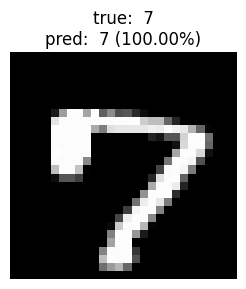

In [150]:
import numpy as np
import torch
import matplotlib.pyplot as plt

classes = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

idx = torch.randint(len(test_dataset), (1,)).item()
sample_image, sample_label = test_dataset[idx]

image_np = sample_image.squeeze().numpy().astype(np.float32)
input_np = np.expand_dims(image_np, axis=(0, -1)) 

output = predictor.predict(input_np)

if isinstance(output, dict) and "predictions" in output:
    output = output["predictions"]

probs = torch.tensor(output, dtype=torch.float32)

confidence, predicted = torch.max(probs, dim=1)

plt.figure(figsize=(3, 3))
plt.imshow(image_np, cmap="gray")
plt.axis("off")
plt.title(
    f"true:  {classes[int(sample_label)]}\n"
    f"pred:  {classes[predicted.item()]} ({confidence.item() * 100:.2f}%)"
)
plt.tight_layout()
plt.show()